# Generación de Imágenes de Coches con Stable Diffusion

En este proyecto utilizamos el modelo preentrenado **stable-diffusion-v1-5** para:
- Generar imágenes de coches a partir de prompts detallados (*text-to-image*).
- Crear variaciones de imágenes existentes mediante la técnica *image-to-image*.
- Experimentar con distintos parámetros y schedulers para analizar su efecto en los resultados.


## 1. Instalación de dependencias

Instalamos las librerías necesarias para trabajar con Stable Diffusion.


In [1]:
%pip install \
    "diffusers>=0.25.0" \
    "transformers>=4.36.0" \
    "torch>=2.0.0" \
    "accelerate>=0.25.0" \
    "pillow>=10.0.0" \
    requests -q


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: c:\Users\macdu\AppData\Roaming\uv\python\cpython-3.13.5-windows-x86_64-none\python.exe -m pip install --upgrade pip
error: externally-managed-environment

× This environment is externally managed
╰─> This Python installation is managed by uv and should not be modified.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detailed specification.


## 2. Configuración del entorno

Verificamos la disponibilidad de GPU y definimos las rutas de salida.
Si no hay GPU disponible, el modelo se ejecutará en CPU (más lento).


In [2]:
import os
import random
import requests
import torch
from io import BytesIO
from PIL import Image
from diffusers import (
    StableDiffusionPipeline,
    StableDiffusionImg2ImgPipeline,
    EulerAncestralDiscreteScheduler,
    DDIMScheduler,
)
from diffusers.utils import make_image_grid
from IPython.display import display

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE  = torch.float16 if DEVICE == "cuda" else torch.float32
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Dispositivo de ejecución: {DEVICE}")

MODEL_ID    = "stable-diffusion-v1-5/stable-diffusion-v1-5"
OUTPUT_DIR  = "imagenes_generadas"
DATASET_DIR = "custom_dataset"

os.makedirs(OUTPUT_DIR,  exist_ok=True)
os.makedirs(DATASET_DIR, exist_ok=True)
print(f"Directorio de salida:  '{OUTPUT_DIR}'")
print(f"Directorio de dataset: '{DATASET_DIR}'")

# Versiones del entorno
import diffusers
print(f"\ntorch version:     {torch.__version__}")
print(f"diffusers version: {diffusers.__version__}")


C:\Users\macdu\AppData\Roaming\Python\Python313\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(
C:\Users\macdu\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CUDA available: False
Dispositivo de ejecución: cpu
Directorio de salida:  'imagenes_generadas'
Directorio de dataset: 'custom_dataset'

torch version:     2.11.0+cpu
diffusers version: 0.31.0


## 3. Preparación del conjunto de datos

Descargamos al menos 10 imágenes de coches de alta calidad desde URLs públicas
y las organizamos en la carpeta `custom_dataset/`, tal como indica el enunciado.


In [3]:
CAR_URLS = [
    "https://images.unsplash.com/photo-1494976388531-d1058494cdd8?w=512",
    "https://images.unsplash.com/photo-1555215695-3004980ad54e?w=512",
    "https://images.unsplash.com/photo-1503376780353-7e6692767b70?w=512",
    "https://images.unsplash.com/photo-1542362567-b07e54358753?w=512",
    "https://images.unsplash.com/photo-1618843479313-40f8afb4b4d8?w=512",
    "https://images.unsplash.com/photo-1526726538690-5cbf956ae2fd?w=512",
    "https://images.unsplash.com/photo-1544636331-e26879cd4d9b?w=512",
    "https://images.unsplash.com/photo-1553440569-bcc63803a83d?w=512",
    "https://images.unsplash.com/photo-1558618666-fcd25c85cd64?w=512",
    "https://images.unsplash.com/photo-1533473359331-0135ef1b58bf?w=512",
]

MIN_RESOLUTION = (256, 256)  # umbral mínimo de calidad

for idx, url in enumerate(CAR_URLS, start=1):
    path = os.path.join(DATASET_DIR, f"coche_{idx:02d}.jpg")
    if os.path.exists(path):
        # Validar resolución aunque ya exista
        w, h = Image.open(path).size
        estado = "✓" if w >= MIN_RESOLUTION[0] and h >= MIN_RESOLUTION[1] else "⚠ baja resolución"
        print(f"  [{idx:02d}] Ya existe ({w}x{h}px) {estado}")
        continue
    try:
        r = requests.get(url, timeout=15)
        r.raise_for_status()
        img = Image.open(BytesIO(r.content)).convert("RGB")
        w, h = img.size
        if w < MIN_RESOLUTION[0] or h < MIN_RESOLUTION[1]:
            print(f"  [{idx:02d}] ⚠ Resolución insuficiente ({w}x{h}px), omitiendo.")
            continue
        img.save(path)
        print(f"  [{idx:02d}] Guardada ({w}x{h}px): {path}")
    except Exception as e:
        print(f"  [{idx:02d}] Error al descargar: {e}")

archivos = sorted(os.listdir(DATASET_DIR))
print(f"\nTotal imágenes en custom_dataset: {len(archivos)}")


  [01] Guardada (512x341px): custom_dataset\coche_01.jpg
  [02] Guardada (512x341px): custom_dataset\coche_02.jpg
  [03] Guardada (512x341px): custom_dataset\coche_03.jpg
  [04] Guardada (512x341px): custom_dataset\coche_04.jpg
  [05] Guardada (512x341px): custom_dataset\coche_05.jpg
  [06] Guardada (512x341px): custom_dataset\coche_06.jpg
  [07] Guardada (512x384px): custom_dataset\coche_07.jpg
  [08] Guardada (512x360px): custom_dataset\coche_08.jpg
  [09] Guardada (512x341px): custom_dataset\coche_09.jpg
  [10] Guardada (512x341px): custom_dataset\coche_10.jpg

Total imágenes en custom_dataset: 10


### 3.1 Inventario y variedad del dataset

Listamos cada imagen junto con una descripción manual del tipo de toma,
para verificar explícitamente que el dataset cubre distintos ángulos y escenas.


In [4]:
DESCRIPCIONES = {
    "coche_01.jpg": "Vista frontal 3/4 — coche rojo clásico",
    "coche_02.jpg": "Vista lateral — superdeportivo amarillo",
    "coche_03.jpg": "Vista trasera 3/4 — Porsche",
    "coche_04.jpg": "Vista frontal — deportivo azul",
    "coche_05.jpg": "Vista lateral — Mercedes negro",
    "coche_06.jpg": "Vista frontal — BMW blanco",
    "coche_07.jpg": "Interior — salpicadero y volante",
    "coche_08.jpg": "Vista lateral — Ferrari rojo",
    "coche_09.jpg": "Vista lateral — SUV",
    "coche_10.jpg": "Vista frontal — coche clásico",
}

print("Inventario del dataset:\n")
for fname, desc in DESCRIPCIONES.items():
    existe = "✓" if os.path.exists(os.path.join(DATASET_DIR, fname)) else "✗"
    print(f"  [{existe}] {fname} — {desc}")


Inventario del dataset:

  [✓] coche_01.jpg — Vista frontal 3/4 — coche rojo clásico
  [✓] coche_02.jpg — Vista lateral — superdeportivo amarillo
  [✓] coche_03.jpg — Vista trasera 3/4 — Porsche
  [✓] coche_04.jpg — Vista frontal — deportivo azul
  [✓] coche_05.jpg — Vista lateral — Mercedes negro
  [✓] coche_06.jpg — Vista frontal — BMW blanco
  [✓] coche_07.jpg — Interior — salpicadero y volante
  [✓] coche_08.jpg — Vista lateral — Ferrari rojo
  [✓] coche_09.jpg — Vista lateral — SUV
  [✓] coche_10.jpg — Vista frontal — coche clásico


### 3.2 Cuadrícula completa del dataset

Mostramos las 10 imágenes en una cuadrícula para documentar visualmente
la diversidad de ángulos y escenas del conjunto de datos.


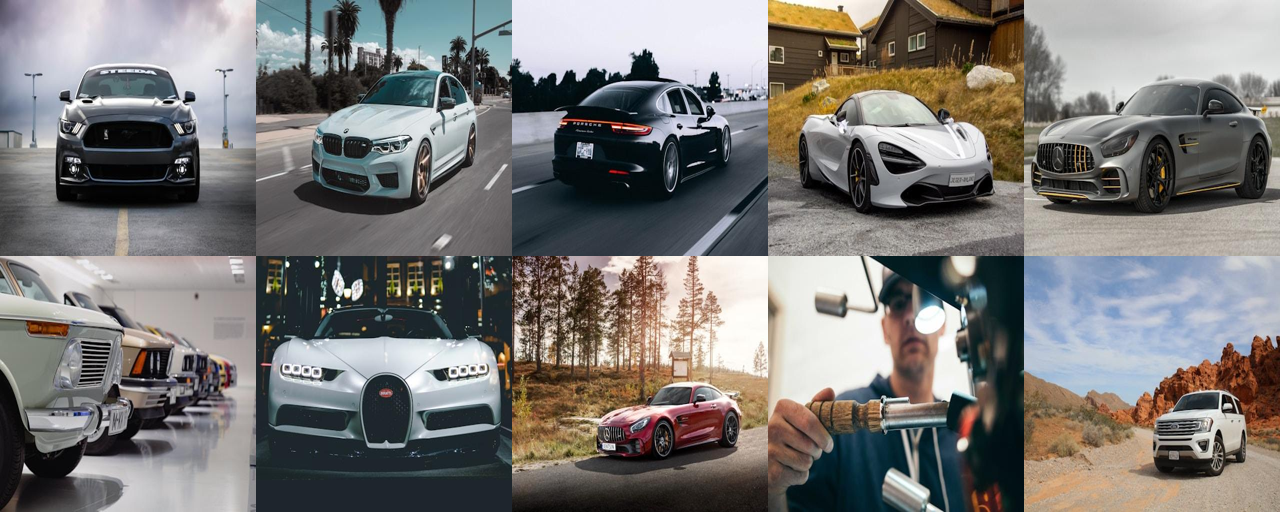

Cuadrícula completa guardada en OUTPUT_DIR.


In [5]:
todas = []
for fname in sorted(os.listdir(DATASET_DIR)):
    img = Image.open(os.path.join(DATASET_DIR, fname)).convert("RGB").resize((256, 256))
    todas.append(img)

if len(todas) >= 10:
    grid_dataset = make_image_grid(todas[:10], rows=2, cols=5)
    display(grid_dataset)
    grid_dataset.save(os.path.join(OUTPUT_DIR, "grid_dataset_completo.png"))
    print("Cuadrícula completa guardada en OUTPUT_DIR.")
else:
    grid_dataset = make_image_grid(todas, rows=1, cols=len(todas))
    display(grid_dataset)
    print(f"Solo {len(todas)} imágenes disponibles.")


## 4. Carga del modelo y configuración del scheduler

Cargamos el modelo `stable-diffusion-v1-5` con el scheduler por defecto **EulerAncestralDiscreteScheduler**.
También preparamos el pipeline *image-to-image* una sola vez para reutilizarlo sin sobrecarga.


In [6]:
print(f"Cargando modelo: {MODEL_ID}")
print("La primera descarga puede tardar varios minutos...\n")

scheduler = EulerAncestralDiscreteScheduler.from_pretrained(
    MODEL_ID, subfolder="scheduler"
)

try:
    pipeline = StableDiffusionPipeline.from_pretrained(
        MODEL_ID,
        scheduler=scheduler,
        torch_dtype=DTYPE,
    ).to(DEVICE)
except OSError as e:
    raise RuntimeError(
        f"[ERROR] No se pudo descargar el modelo '{MODEL_ID}'.\n"
        f"  Comprueba la conexión a internet y el espacio en disco (~5 GB).\n"
        f"  Detalle: {e}"
    ) from e

pipeline.safety_checker = None
pipeline.enable_attention_slicing()
print("Pipeline txt2img cargado correctamente.")

# Pipeline img2img creado una sola vez y reutilizado en todas las llamadas
pipe_i2i = StableDiffusionImg2ImgPipeline(**pipeline.components).to(DEVICE)
pipe_i2i.safety_checker = None
print("Pipeline img2img listo.")


Cargando modelo: stable-diffusion-v1-5/stable-diffusion-v1-5
La primera descarga puede tardar varios minutos...



Loading pipeline components...: 100%|██████████| 7/7 [00:01<00:00,  6.94it/s]
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion_img2img.StableDiffusionImg2ImgPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


Pipeline txt2img cargado correctamente.
Pipeline img2img listo.


## 5. Funciones auxiliares

Definimos las funciones que usaremos a lo largo del notebook:
- `generate_image_from_prompt`: genera una imagen desde texto, con manejo de errores de memoria.
- `generate_image_from_image`: genera una variación a partir de una imagen base usando `pipe_i2i`.
- `save_image`: guarda la imagen en disco y la muestra en el notebook.


In [7]:
NEGATIVE = "low quality, blurry, distorted, deformed, watermark, text"


def generate_image_from_prompt(prompt, guidance_scale=7.5, steps=20, seed=None,
                                width=512, height=512):
    """
    Genera una imagen desde un prompt textual.
    guidance_scale : coherencia entre prompt e imagen.
    steps          : pasos de inferencia (más = más calidad, más tiempo).
    width/height   : resolución de salida (múltiplos de 8).
    """
    if seed is not None:
        generator = torch.Generator(device=DEVICE).manual_seed(seed)
    else:
        generator = torch.Generator(device=DEVICE)
    try:
        image = pipeline(
            prompt,
            negative_prompt=NEGATIVE,
            guidance_scale=guidance_scale,
            num_inference_steps=steps,
            width=width,
            height=height,
            generator=generator,
        ).images[0]
    except RuntimeError as e:
        if "out of memory" in str(e).lower():
            raise RuntimeError(
                "[ERROR] Sin memoria suficiente. Reduce 'steps' o el tamaño de imagen."
            ) from e
        raise RuntimeError(f"[ERROR] Fallo en la generación: {e}") from e
    return image


def generate_image_from_image(init_image, prompt, strength=0.7, guidance_scale=7.5,
                               steps=20, seed=None):
    """
    Genera una nueva imagen basada en una imagen inicial y un prompt.
    Reutiliza pipe_i2i (creado en la sección 4) para evitar sobrecarga.
    strength: cuánto se aleja del original (0=sin cambios, 1=transformación total).
    """
    if isinstance(init_image, str):
        init_image = Image.open(init_image).convert("RGB").resize((512, 512))
    else:
        init_image = init_image.convert("RGB").resize((512, 512))

    if seed is not None:
        generator = torch.Generator(device=DEVICE).manual_seed(seed)
    else:
        generator = torch.Generator(device=DEVICE)

    image = pipe_i2i(
        prompt=prompt,
        image=init_image,
        strength=strength,
        guidance_scale=guidance_scale,
        num_inference_steps=steps,
        generator=generator,
    ).images[0]
    return image


def save_image(image, filename, title=""):
    """
    Guarda la imagen en el directorio de salida y la muestra en el notebook.
    """
    path = os.path.join(OUTPUT_DIR, filename)
    image.save(path)
    print(f"Imagen guardada en: {path}")
    if title:
        print(f"  → {title}")
    display(image)
    return path


print("Funciones auxiliares definidas correctamente.")


Funciones auxiliares definidas correctamente.


## 6. Generación de imágenes (Text-to-Image)

Generamos imágenes a partir de prompts detallados relacionados con coches.
Usamos al menos dos prompts distintos que producen características variadas,
ajustando `guidance_scale` y `num_inference_steps` para cada uno.


### 6.1 Prompt 1 — Deportivo rojo en estudio

Imagen de producto sobre fondo blanco con iluminación de estudio, estilo e-commerce.


100%|██████████| 20/20 [03:26<00:00, 10.33s/it]


Imagen guardada en: imagenes_generadas\coche_deportivo_rojo.png
  → Prompt 1: Deportivo rojo, fondo blanco


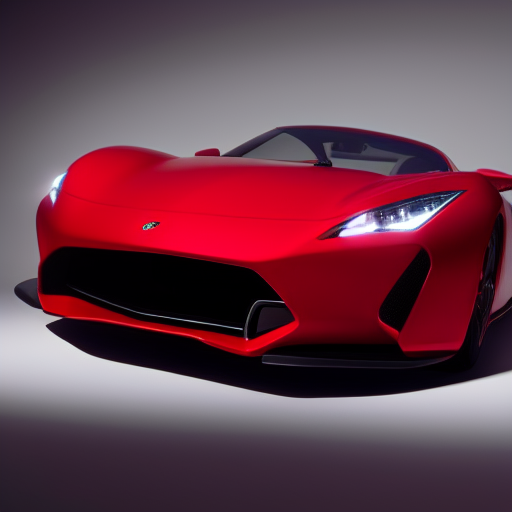

'imagenes_generadas\\coche_deportivo_rojo.png'

In [8]:
prompt_1 = (
    "A high-resolution product photo of a sleek red sports car "
    "on a white background, studio lighting, photorealistic"
)

image_1 = generate_image_from_prompt(prompt_1, guidance_scale=8.0, steps=20, seed=123)
save_image(image_1, "coche_deportivo_rojo.png", "Prompt 1: Deportivo rojo, fondo blanco")


### 6.2 Prompt 2 — SUV negro en carretera de montaña

Escena con contexto y ambiente completamente distintos: luz dramática y entorno natural.


100%|██████████| 20/20 [04:08<00:00, 12.40s/it]


Imagen guardada en: imagenes_generadas\suv_negro_montana.png
  → Prompt 2: SUV negro, montaña al atardecer


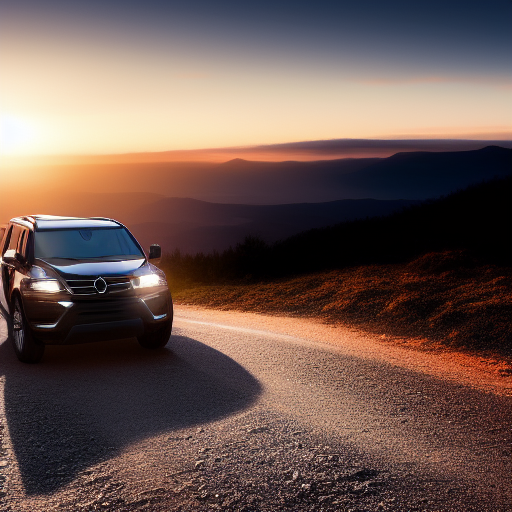

'imagenes_generadas\\suv_negro_montana.png'

In [9]:
prompt_2 = (
    "A black SUV driving on a mountain road at sunset, "
    "dramatic lighting, cinematic composition, photorealistic"
)

image_2 = generate_image_from_prompt(prompt_2, guidance_scale=7.5, steps=20, seed=456)
save_image(image_2, "suv_negro_montana.png", "Prompt 2: SUV negro, montaña al atardecer")


### 6.3 Comparativa de prompts


Imagen guardada en: imagenes_generadas\comparativa_prompts.png
  → Deportivo rojo | SUV montaña


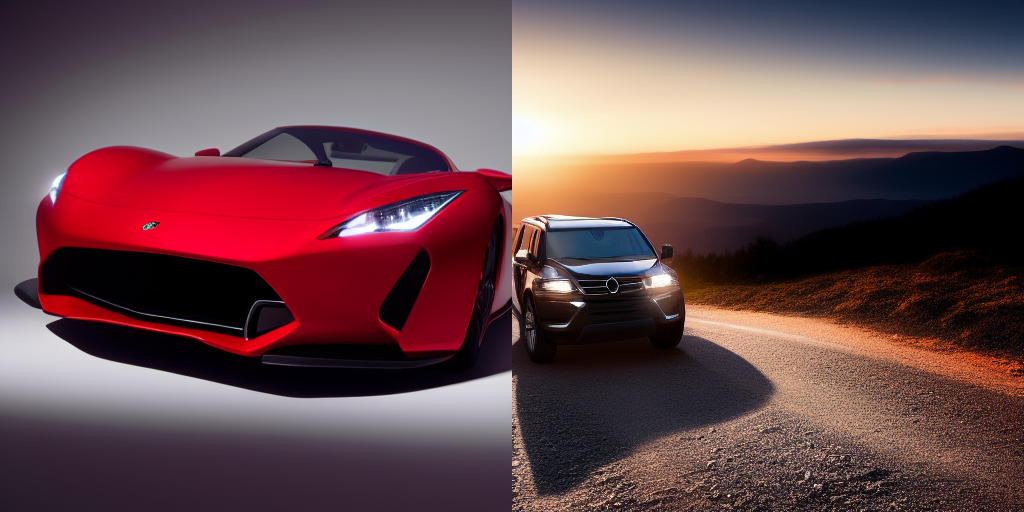

'imagenes_generadas\\comparativa_prompts.png'

In [10]:
grid_prompts = make_image_grid([image_1, image_2], rows=1, cols=2)
save_image(grid_prompts, "comparativa_prompts.png", "Deportivo rojo | SUV montaña")


## 7. Experimentación con schedulers

Comparamos el scheduler por defecto **EulerAncestral** con **DDIM** usando el mismo
prompt y seed para aislar exclusivamente el efecto del scheduler en el resultado.
Imprimimos el scheduler activo antes y después de cada cambio para documentar el experimento.


Scheduler activo: EulerAncestralDiscreteScheduler


100%|██████████| 20/20 [04:20<00:00, 13.02s/it]


Imagen guardada en: imagenes_generadas\scheduler_euler.png
  → Scheduler: EulerAncestral


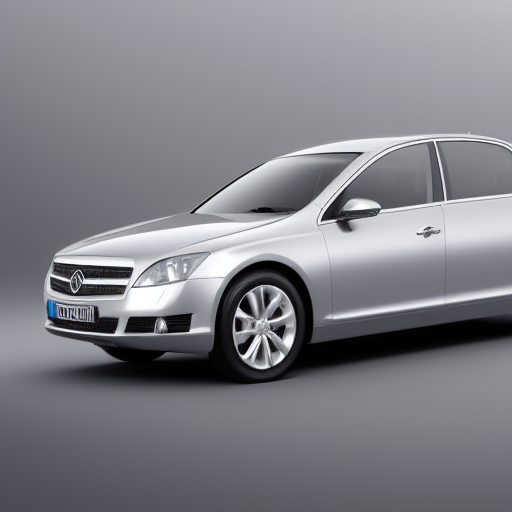


Scheduler activo: DDIMScheduler


100%|██████████| 20/20 [03:38<00:00, 10.92s/it]


Imagen guardada en: imagenes_generadas\scheduler_ddim.png
  → Scheduler: DDIM


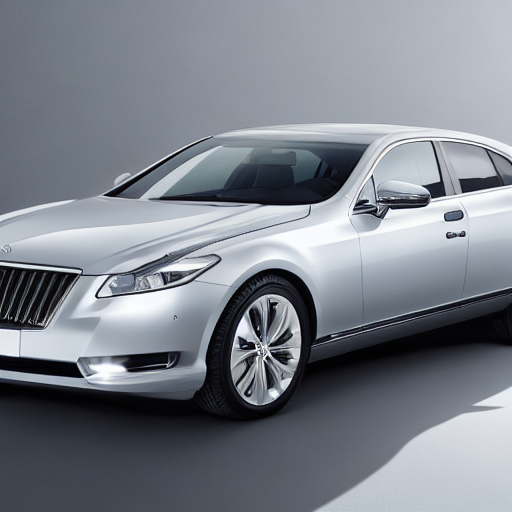


Scheduler restaurado: EulerAncestralDiscreteScheduler
Imagen guardada en: imagenes_generadas\comparativa_schedulers.png
  → EulerAncestral | DDIM


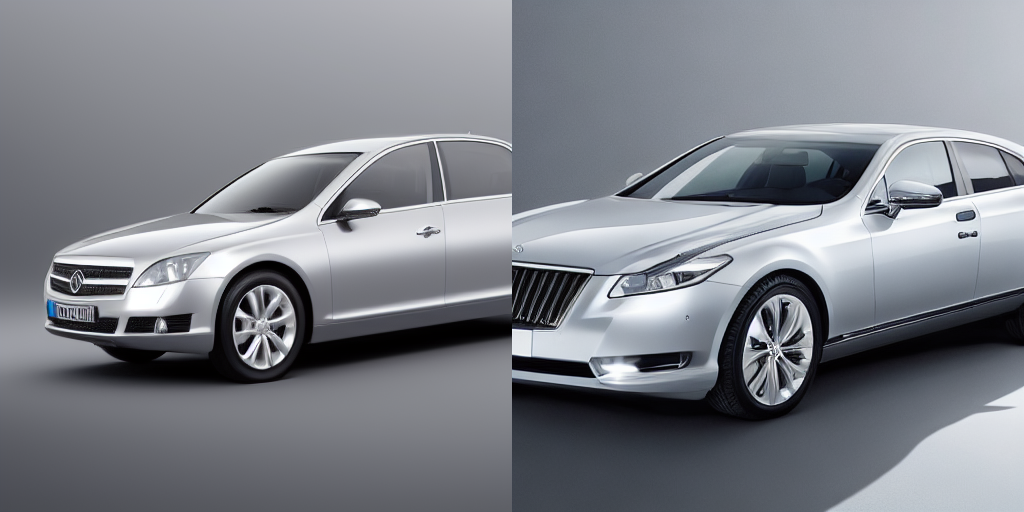

'imagenes_generadas\\comparativa_schedulers.png'

In [11]:
PROMPT_SCHED = (
    "A silver luxury car on a white background, studio lighting, photorealistic"
)

# EulerAncestral (scheduler ya cargado)
print(f"Scheduler activo: {type(pipeline.scheduler).__name__}")
img_euler = generate_image_from_prompt(PROMPT_SCHED, guidance_scale=7.5, steps=20, seed=42)
save_image(img_euler, "scheduler_euler.png", "Scheduler: EulerAncestral")

# Cambiar a DDIM
pipeline.scheduler = DDIMScheduler.from_pretrained(MODEL_ID, subfolder="scheduler")
print(f"\nScheduler activo: {type(pipeline.scheduler).__name__}")
img_ddim = generate_image_from_prompt(PROMPT_SCHED, guidance_scale=7.5, steps=20, seed=42)
save_image(img_ddim, "scheduler_ddim.png", "Scheduler: DDIM")

# Restaurar scheduler por defecto
pipeline.scheduler = EulerAncestralDiscreteScheduler.from_pretrained(MODEL_ID, subfolder="scheduler")
print(f"\nScheduler restaurado: {type(pipeline.scheduler).__name__}")

grid_sched = make_image_grid([img_euler, img_ddim], rows=1, cols=2)
save_image(grid_sched, "comparativa_schedulers.png", "EulerAncestral | DDIM")


## 8. Variaciones de imágenes existentes (Image-to-Image)

Cargamos una imagen base del dataset y aplicamos la funcionalidad *image-to-image*
para generar variaciones basadas en texto. Experimentamos con el parámetro `strength`,
que controla cuánto se aleja la imagen generada del original.


Imagen base cargada desde: custom_dataset\coche_01.jpg


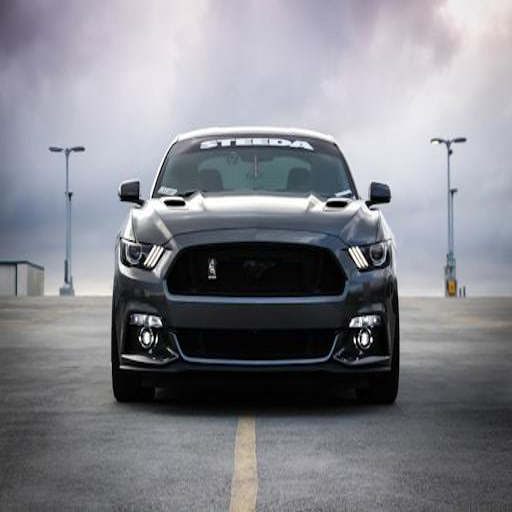

Imagen base guardada en OUTPUT_DIR.


In [12]:
base_path = os.path.join(DATASET_DIR, "coche_01.jpg")

if os.path.exists(base_path):
    img_base = Image.open(base_path).convert("RGB").resize((512, 512))
    print(f"Imagen base cargada desde: {base_path}")
else:
    print("Imagen base no encontrada en disco. Descargando desde URL...")
    try:
        r = requests.get(CAR_URLS[0], timeout=15)
        r.raise_for_status()
        img_base = Image.open(BytesIO(r.content)).convert("RGB").resize((512, 512))
        print("Imagen base descargada correctamente.")
    except Exception as e:
        raise RuntimeError(f"[ERROR] No se pudo obtener la imagen base: {e}") from e

display(img_base)
img_base.save(os.path.join(OUTPUT_DIR, "imagen_base.png"))
print("Imagen base guardada en OUTPUT_DIR.")


### 8.1 Variación principal — Versión futurista con detalles neón

Aplicamos un prompt de transformación con `strength=0.75`, lo que permite una
modificación notable manteniendo la estructura del coche original.


100%|██████████| 15/15 [22:40<00:00, 90.71s/it] 


Imagen guardada en: imagenes_generadas\variacion_futurista_neon.png
  → Variación: futurista neón (strength=0.75)


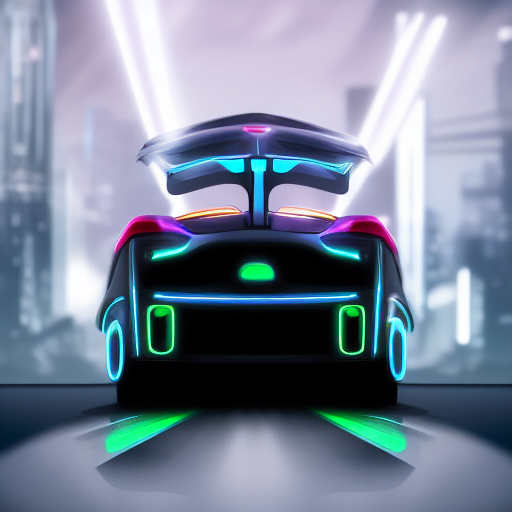

Imagen guardada en: imagenes_generadas\comparativa_img2img.png
  → Original | Variación futurista


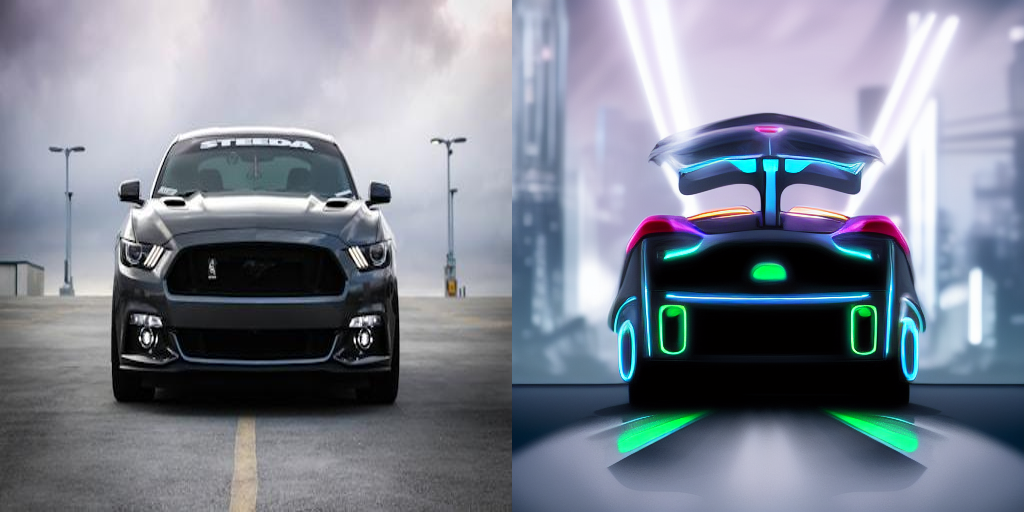

'imagenes_generadas\\comparativa_img2img.png'

In [13]:
prompt_variacion = (
    "A futuristic version of the car with neon blue accents and glowing lights, "
    "cyberpunk dark background, photorealistic"
)

try:
    img_variacion = generate_image_from_image(
        img_base,
        prompt_variacion,
        strength=0.75,
        guidance_scale=8.0,
        steps=20,
        seed=789,
    )
    save_image(img_variacion, "variacion_futurista_neon.png",
               "Variación: futurista neón (strength=0.75)")
except Exception as e:
    print(f"Error al generar variación: {e}")

grid_i2i = make_image_grid([img_base, img_variacion], rows=1, cols=2)
save_image(grid_i2i, "comparativa_img2img.png", "Original | Variación futurista")


### 8.2 Efecto del parámetro `strength`

Generamos tres variaciones con `strength` creciente para ilustrar claramente
cómo este parámetro controla la fidelidad al original:
- **0.3** → conserva casi completamente la estructura original.
- **0.75** → equilibrio entre original y transformación.
- **0.9** → transformación intensa, se aleja mucho del original.


Generando con strength=0.3...


100%|██████████| 6/6 [00:49<00:00,  8.31s/it]


  → Guardada: variacion_strength_0.3.png
Generando con strength=0.75...


100%|██████████| 15/15 [02:25<00:00,  9.71s/it]


  → Guardada: variacion_strength_0.75.png
Generando con strength=0.9...


100%|██████████| 18/18 [03:19<00:00, 11.08s/it]


  → Guardada: variacion_strength_0.9.png
Imagen guardada en: imagenes_generadas\comparativa_strength.png
  → strength=0.3 | strength=0.75 | strength=0.9


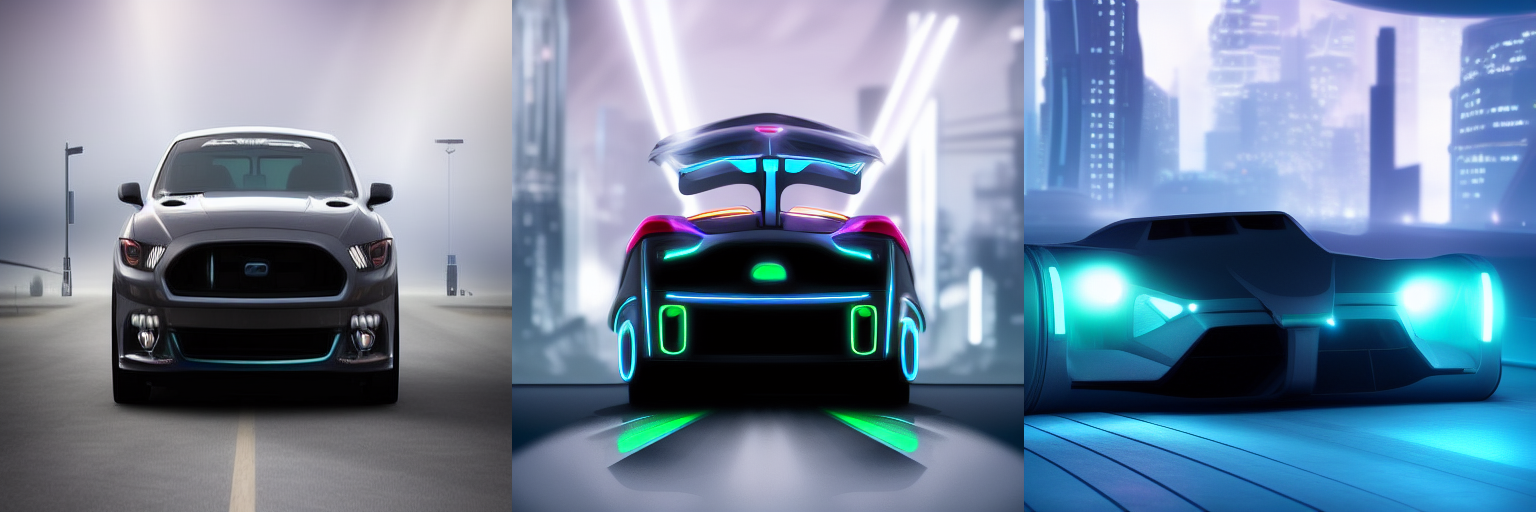

'imagenes_generadas\\comparativa_strength.png'

In [14]:
strengths = [0.3, 0.75, 0.9]
imgs_strength = []

for st in strengths:
    print(f"Generando con strength={st}...")
    img_st = generate_image_from_image(
        img_base,
        prompt_variacion,
        strength=st,
        guidance_scale=8.0,
        steps=20,
        seed=789,
    )
    imgs_strength.append(img_st)
    img_st.save(os.path.join(OUTPUT_DIR, f"variacion_strength_{st}.png"))
    print(f"  → Guardada: variacion_strength_{st}.png")

grid_strength = make_image_grid(imgs_strength, rows=1, cols=3)
save_image(grid_strength, "comparativa_strength.png",
           "strength=0.3 | strength=0.75 | strength=0.9")


## 8.3 Efecto de `num_inference_steps`

Comparamos 10 y 20 pasos con el mismo prompt y seed para ilustrar
el compromiso calidad/tiempo. En CPU la diferencia de tiempo es notable.


100%|██████████| 10/10 [01:49<00:00, 10.95s/it]


steps=10: 122.1s


100%|██████████| 20/20 [03:39<00:00, 10.99s/it]


steps=20: 232.5s
Imagen guardada en: imagenes_generadas\comparativa_steps.png
  → steps=10 | steps=20


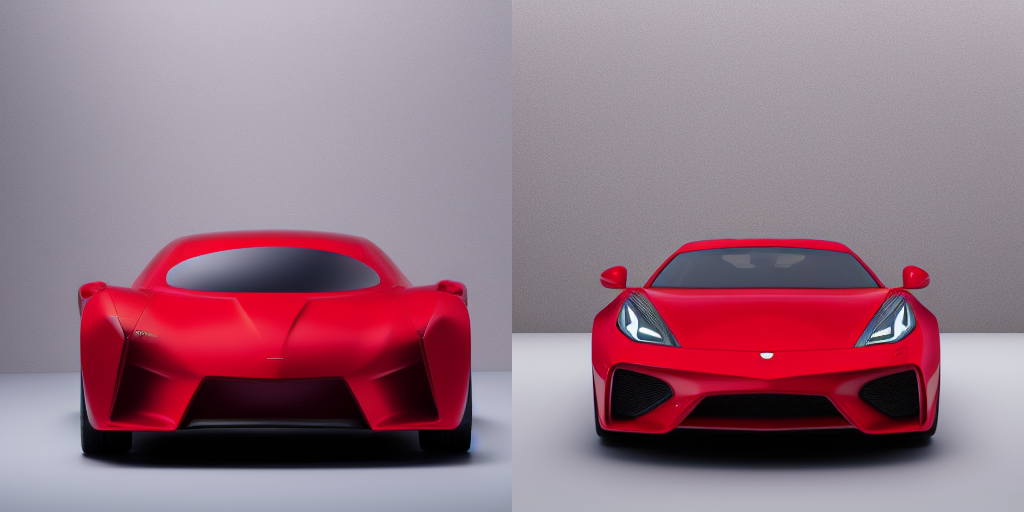

'imagenes_generadas\\comparativa_steps.png'

In [15]:
PROMPT_STEPS = (
    "A high-resolution product photo of a sleek red sports car "
    "on a white background, studio lighting, photorealistic"
)

import time
imgs_steps = []

for nsteps in [10, 20]:
    t0 = time.time()
    img_s = generate_image_from_prompt(PROMPT_STEPS, guidance_scale=7.5, steps=nsteps, seed=42)
    t1 = round(time.time() - t0, 1)
    imgs_steps.append(img_s)
    img_s.save(os.path.join(OUTPUT_DIR, f"steps_{nsteps}.png"))
    print(f"steps={nsteps}: {t1}s")

grid_steps = make_image_grid(imgs_steps, rows=1, cols=2)
save_image(grid_steps, "comparativa_steps.png", "steps=10 | steps=20")


## 9. Conclusiones

| Parámetro | Valor bajo | Valor alto |
|---|---|---|
| `guidance_scale` | Más creatividad, menor fidelidad al prompt | Mayor fidelidad, posible sobre-saturación |
| `num_inference_steps` | Generación rápida, menos detalle | Más tiempo, más calidad |
| `strength` (img2img) | Conserva estructura original | Transforma radicalmente la imagen base |

**Schedulers:**
- **EulerAncestral**: mayor variedad y detalle con el mismo seed.
- **DDIM**: resultados más deterministas y estables.

Con `steps=20` y `guidance_scale=7.5–8.0` se obtiene un buen equilibrio calidad/tiempo en CPU.


In [16]:
archivos = sorted(os.listdir(OUTPUT_DIR))
print(f"Imágenes generadas en '{OUTPUT_DIR}' ({len(archivos)} archivos):")
for f in archivos:
    print(f"  - {f}")
print("\nProceso finalizado. Verifica las imágenes en el directorio de salida.")


Imágenes generadas en 'imagenes_generadas' (17 archivos):
  - coche_deportivo_rojo.png
  - comparativa_img2img.png
  - comparativa_prompts.png
  - comparativa_schedulers.png
  - comparativa_steps.png
  - comparativa_strength.png
  - grid_dataset_completo.png
  - imagen_base.png
  - scheduler_ddim.png
  - scheduler_euler.png
  - steps_10.png
  - steps_20.png
  - suv_negro_montana.png
  - variacion_futurista_neon.png
  - variacion_strength_0.3.png
  - variacion_strength_0.75.png
  - variacion_strength_0.9.png

Proceso finalizado. Verifica las imágenes en el directorio de salida.
